# Data preparation

## imports

In [21]:
from datasets import load_dataset

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load dataset and transform into Pandas df

In [22]:
dataset = load_dataset(
    "coastalcph/lex_glue",
    "ledgar",
    cache_dir="../raw_data"
)

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
})

In [23]:
dataset.keys()

dict_keys(['train', 'test', 'validation'])

In [24]:
for split in dataset.keys():
    print(split, len(dataset[split]))

train 60000
test 10000
validation 10000


In [25]:
dataset["train"][0]

{'text': 'Except as otherwise set forth in this Debenture, the Company, for itself and its legal representatives, successors and assigns, expressly waives presentment, protest, demand, notice of dishonor, notice of nonpayment, notice of maturity, notice of protest, presentment for the purpose of accelerating maturity, and diligence in collection.',
 'label': 97}

In [26]:
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

train_df.head()

,text,label
0,Except as otherwise set forth in this Debentur...,97
1,No ERISA Event has occurred or is reasonably e...,39
2,This Amendment may be executed by one or more ...,26
3,"From time to time, as and when required by the...",45
4,"Commencing March 7, 2016 and during the Employ...",11


## 2. EDA

In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    60000 non-null  object
 1   label   60000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 937.6+ KB


In [27]:
train_df.isna().sum()

text     0
label    0
dtype: int64

In [28]:
train_df.columns

Index(['text', 'label'], dtype='object')

In [29]:
dataset["train"].features

{'text': Value('string'),
 'label': ClassLabel(names=['Adjustments', 'Agreements', 'Amendments', 'Anti-Corruption Laws', 'Applicable Laws', 'Approvals', 'Arbitration', 'Assignments', 'Assigns', 'Authority', 'Authorizations', 'Base Salary', 'Benefits', 'Binding Effects', 'Books', 'Brokers', 'Capitalization', 'Change In Control', 'Closings', 'Compliance With Laws', 'Confidentiality', 'Consent To Jurisdiction', 'Consents', 'Construction', 'Cooperation', 'Costs', 'Counterparts', 'Death', 'Defined Terms', 'Definitions', 'Disability', 'Disclosures', 'Duties', 'Effective Dates', 'Effectiveness', 'Employment', 'Enforceability', 'Enforcements', 'Entire Agreements', 'Erisa', 'Existence', 'Expenses', 'Fees', 'Financial Statements', 'Forfeitures', 'Further Assurances', 'General', 'Governing Laws', 'Headings', 'Indemnifications', 'Indemnity', 'Insurances', 'Integration', 'Intellectual Property', 'Interests', 'Interpretations', 'Jurisdictions', 'Liens', 'Litigations', 'Miscellaneous', 'Modifications

In [30]:
label_names = dataset["train"].features["label"].names
label_names[:10]

['Adjustments',
 'Agreements',
 'Amendments',
 'Anti-Corruption Laws',
 'Applicable Laws',
 'Approvals',
 'Arbitration',
 'Assignments',
 'Assigns',
 'Authority']

In [31]:
train_df["label_name"] = train_df["label"].apply(lambda x: label_names[x])
val_df["label_name"] = val_df["label"].apply(lambda x: label_names[x])
test_df["label_name"] = test_df["label"].apply(lambda x: label_names[x])

train_df.head()

,text,label,label_name
0,Except as otherwise set forth in this Debentur...,97,Waivers
1,No ERISA Event has occurred or is reasonably e...,39,Erisa
2,This Amendment may be executed by one or more ...,26,Counterparts
3,"From time to time, as and when required by the...",45,Further Assurances
4,"Commencing March 7, 2016 and during the Employ...",11,Base Salary


In [32]:
train_df["label_name"].value_counts().head(20)

label_name
Governing Laws          3167
Notices                 2493
Counterparts            2427
Entire Agreements       2340
Severability            1808
Survival                1469
Amendments              1467
Assignments             1327
Expenses                1224
Terms                   1166
Terminations            1112
Insurances              1104
Taxes                   1089
Litigations             1034
Confidentiality         1012
Further Assurances      1009
General                  976
Compliance With Laws     960
Indemnifications         936
Waivers                  878
Name: count, dtype: int64

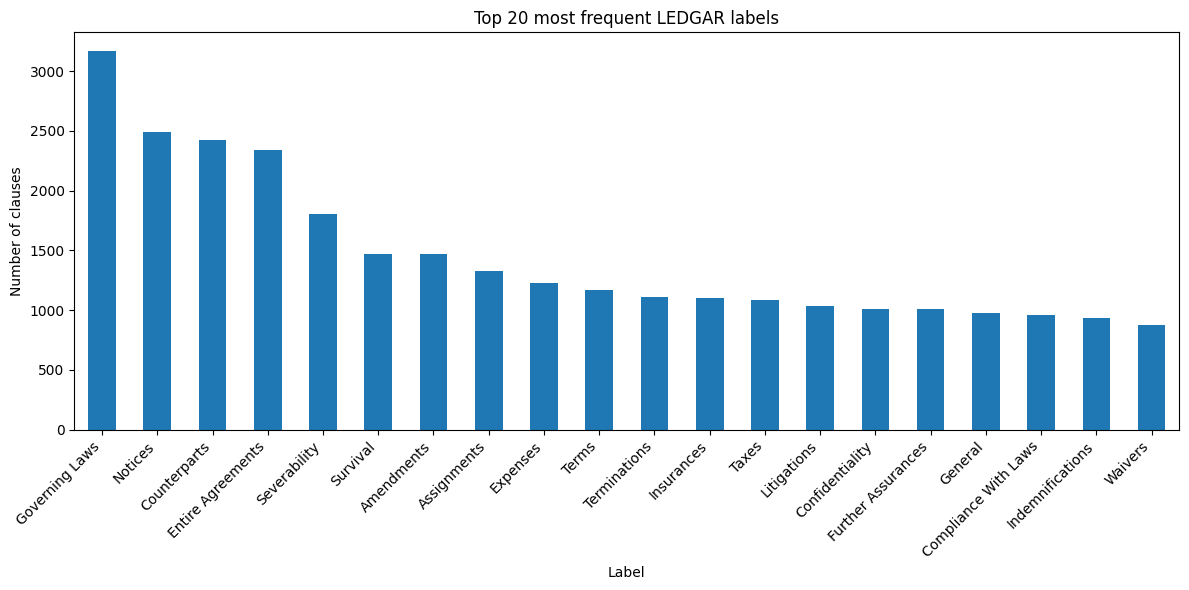

In [33]:
plt.figure(figsize=(12, 6))
train_df["label_name"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 most frequent LEDGAR labels")
plt.xlabel("Label")
plt.ylabel("Number of clauses")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Initial label distribution

The LEDGAR training set contains a multi-class label structure with clearly recurring legal clause categories.

The most frequent labels include `Governing Laws`, `Notices`, `Counterparts`, `Entire Agreements`, and `Severability`. These categories each contain a relatively high number of examples, which makes them suitable for a first supervised baseline model.

The distribution is not perfectly balanced: the most frequent label has more than 3,000 examples, while the 20th most frequent label has below 1,000 examples. This means that accuracy alone may not be sufficient for evaluation. We should also use macro F1 or weighted F1 to better understand model performance across labels.

For the first baseline, we can either:
- train on all LEDGAR labels, or
- start with the top 15–20 labels to build and validate the first end-to-end pipeline faster.


In [17]:
train_df["label_name"].value_counts().tail(20)

label_name
Disability                    263
Existence                     258
Modifications                 255
Agreements                    252
Enforceability                244
Submission To Jurisdiction    238
Effectiveness                 229
Jurisdictions                 202
Enforcements                  201
Positions                     190
Approvals                     178
Consent To Jurisdiction       175
Costs                         168
Venues                        131
Powers                        125
Sanctions                     118
Anti-Corruption Laws          106
Qualifications                 47
Assigns                        31
Books                          23
Name: count, dtype: int64

In [34]:
num_labels = train_df["label_name"].nunique()
num_labels

100

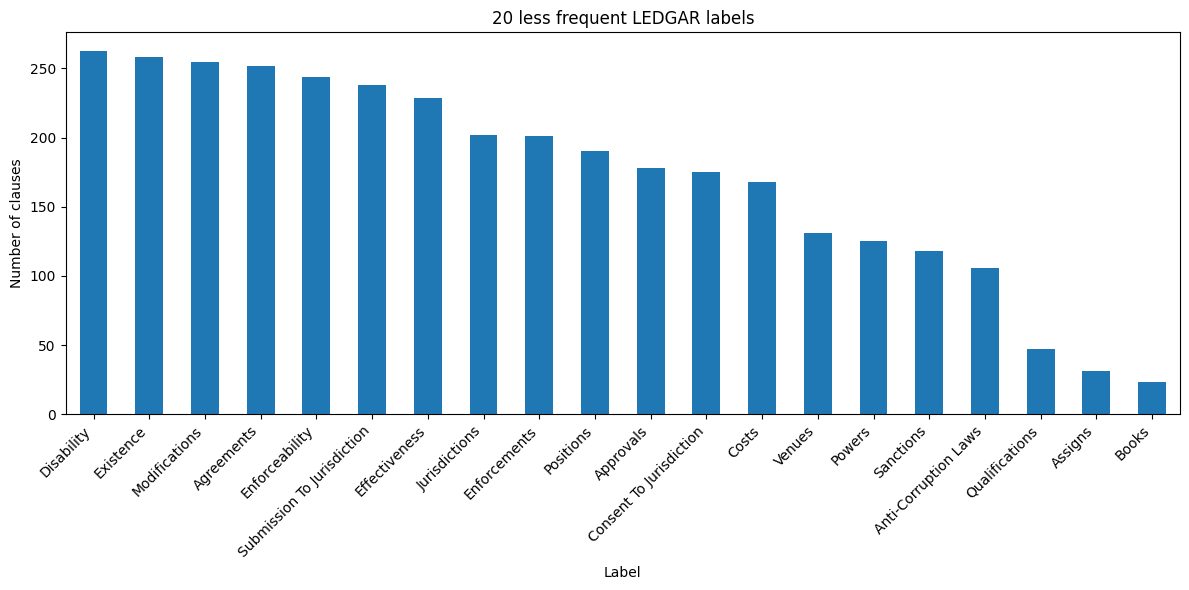

In [35]:
plt.figure(figsize=(12, 6))
train_df["label_name"].value_counts().tail(20).plot(kind="bar")
plt.title("20 less frequent LEDGAR labels")
plt.xlabel("Label")
plt.ylabel("Number of clauses")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Class imbalance observation

The label distribution shows a strong imbalance between frequent and rare clause categories.

While the most frequent labels contain thousands of examples, the least frequent labels contain only a few dozen examples. This means that a simple accuracy score may be misleading: a model could perform well on frequent labels while performing poorly on rare labels.

## Label coverage

In [37]:
label_counts = train_df["label_name"].value_counts()
total_count = label_counts.sum()

for n in [10, 20, 30]:
    coverage = label_counts.head(n).sum() / total_count
    print(f"Top {n} labels cover {coverage:.2%} of the training dataset.")

Top 10 labels cover 31.48% of the training dataset.
Top 20 labels cover 48.33% of the training dataset.
Top 30 labels cover 60.09% of the training dataset.


## Distribution of clause word count

In [38]:
train_df["text_length"] = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().str.len()

train_df[["text_length", "word_count"]].describe()

,text_length,word_count
count,60000.000000,60000.000000
mean,707.675533,113.904267
std,600.133099,96.265631
min,22.000000,3.000000
25%,299.000000,48.000000
50%,532.000000,86.000000
75%,919.000000,148.000000
max,7803.000000,1215.000000


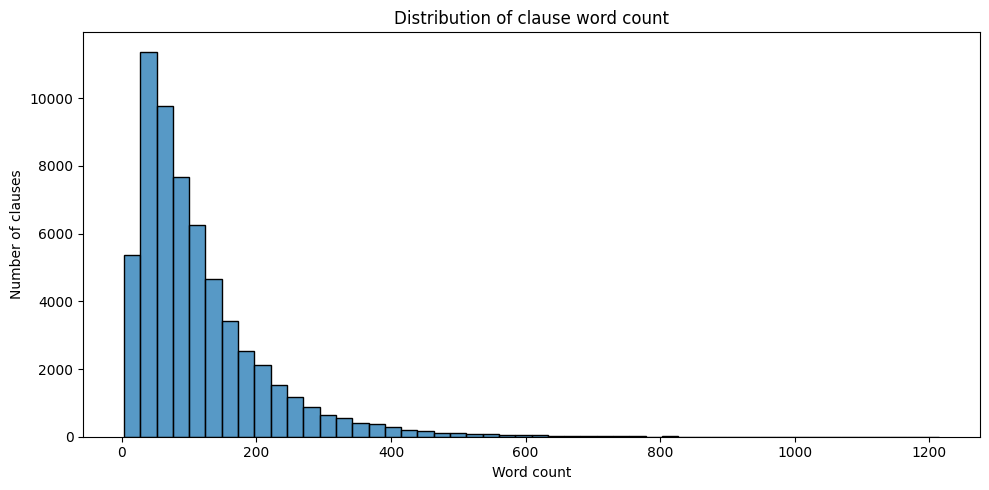

In [41]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df["word_count"], bins=50)
plt.title("Distribution of clause word count")
plt.xlabel("Word count")
plt.ylabel("Number of clauses")
plt.tight_layout()
plt.show()

### Text length distribution

The word count distribution is strongly right-skewed. Most clauses are relatively short, but there are also long outlier clauses with several hundred words, and a few examples above 1,000 words.

This is important for preprocessing and modeling. Very short clauses may contain limited context, while very long clauses may contain multiple legal concepts or noisy text. For the first baseline, we will keep the full dataset unchanged in order to build a working model quickly.

In [42]:
train_df.sort_values("word_count").head(10)[["label_name", "word_count", "text"]]

,label_name,word_count,text
23049,Financial Statements,3,Undisclosed Liabilities .
43277,Positions,3,Chief Financial Officer.
55241,Assignments,4,Prepayments; Reallocations; Reconciliation .
50418,Governing Laws,4,SECTION 11.17 GOVERNING LAW.
43027,Successors,4,"Binding Agreement, Assignment ."
45748,Solvency,4,The Transferor is Solvent.
5134,Expenses,4,Indemnity; Damage Waiver .
47476,Insurances,4,See Schedule 10.3(g) .
13700,Taxes,4,Australian Tax Consolidation .
25414,Waivers,4,Limitation of Waiver .


In [43]:
train_df.sort_values("word_count", ascending=False).head(10)[["label_name", "word_count", "text"]]

,label_name,word_count,text
12950,Warranties,1215,Company represents and warrants to Investor th...
12848,Warranties,1174,Company represents and warrants to Investor th...
21606,Notices,1167,(a) All notices and other communications provi...
36152,Warranties,1166,Company represents and warrants to Investor th...
12734,Warranties,1164,Company represents and warrants to Investor th...
50318,Warranties,1132,Company represents and warrants to Investor th...
10648,Warranties,1083,Company represents and warrants to Investor th...
537,Confidentiality,981,Except as otherwise provided in this Section 1...
37720,Transactions With Affiliates,952,None of the U.S. Borrower or any Restricted Su...
13243,Taxes,945,I t h a s f i l e d ( o r ob t a in e d eff e ...


In [44]:
train_df["word_count"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    60000.000000
mean       113.904267
std         96.265631
min          3.000000
50%         86.000000
75%        148.000000
90%        234.000000
95%        305.000000
99%        471.000000
max       1215.000000
Name: word_count, dtype: float64